In [1]:
import torch, torchvision
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
DEVICE = torch.device('cuda')
EPOCHS = 12

In [4]:
def plt_img(img):
    np_img = img.permute(1, 2, 0).cpu().numpy()
    plt.imshow(np_img)
    plt.axis("off")
    plt.show()

In [5]:
def denormalize(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    mean = torch.tensor(mean).view(3,1,1).to(tensor.device)
    std = torch.tensor(std).view(3,1,1).to(tensor.device)
    return (tensor * std + mean).clamp(0, 1)

In [6]:
transform = transforms.Compose([
    transforms.Resize(512),                  # resize shorter side to 512
    transforms.RandomCrop(256),               # then random crop to 256x256
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
# content = transform(Image.open(r'content.png'))
# style = transform(Image.open(r'style.jpg'))
# plt_img(denormalize(content))
# plt_img(denormalize(style))

In [7]:
class FrozenEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.vggEncoder = torchvision.models.vgg19(pretrained=True).features[:21]
        
        for i, layer in enumerate(self.vggEncoder):
            if isinstance(layer, nn.MaxPool2d):
                self.vggEncoder[i] = nn.AvgPool2d(
                    kernel_size=layer.kernel_size,
                    stride=layer.stride,
                    padding=layer.padding
                )

        for param in self.vggEncoder.parameters():
            param.requires_grad = False
        
        self.vggEncoder.eval()
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        )

    def forward(self, img):
        img = self.normalize(img)
        conv1_1 = self.vggEncoder[:2](img)
        conv2_1 = self.vggEncoder[2:7](conv1_1)
        conv3_1 = self.vggEncoder[7:12](conv2_1)
        conv4_1 = self.vggEncoder[12:](conv3_1)

        return  {
            'conv1_1': conv1_1,
            'conv2_1': conv2_1,
            'conv3_1': conv3_1,
            'conv4_1': conv4_1,
        }


In [8]:
class Presets():
    def __init__(self, content, style, frozenEncoder):
        
        self.style = style.to(DEVICE)
        self.content = content.to(DEVICE)
        self.model = frozenEncoder
        self.model.to(DEVICE)

        with torch.no_grad():
            self.sDict = self.model(self.style)

        with torch.no_grad():
            sconv4_1 = self.sDict['conv4_1'] #(B, C, W, H)
            self.s_mean_conv4_1 = sconv4_1.mean(dim=(2,3), keepdim=True)
            self.s_std_conv4_1  = sconv4_1.std(dim=(2,3), keepdim=True)

            self.cDict = self.model(self.content)

        self.s_mean, self.s_std = {}, {}
        
        for i in self.sDict:
            self.s_mean[i] = self.sDict[i].mean(dim=(2,3), keepdim=True)
            self.s_std[i]  = self.sDict[i].std(dim=(2,3), keepdim=True)

        with torch.no_grad():
            c_mean = self.cDict['conv4_1'].mean(dim=(2,3), keepdim=True)
            c_std  = self.cDict['conv4_1'].std(dim=(2,3), keepdim=True)

            conv4_1 = (self.cDict['conv4_1']-c_mean)/(c_std+1e-10)
            self.t = (conv4_1*self.s_std_conv4_1)+self.s_mean_conv4_1

In [22]:
class AdaIN(nn.Module):
    def __init__(self, presets):
        super().__init__()
        self.presets = presets
        self.s_mean = presets.s_mean_conv4_1
        self.s_std  = presets.s_std_conv4_1
        
    def forward(self, conv4_1):
        c_mean = conv4_1.mean(dim=(2,3), keepdim=True)
        c_std  = conv4_1.std(dim=(2,3), keepdim=True)

        t = conv4_1
        conv4_1 = (conv4_1-c_mean)/(c_std+1e-10)
        conv4_1 = (conv4_1*self.s_std)+self.s_mean
        a = 0.2
        return (1-a)*conv4_1 + a*t

In [10]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=512, out_channels=256, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=256, out_channels=128, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=128, out_channels=64, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,3)),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels=64, out_channels=3, kernel_size=(3,3)),
        )

    def forward(self, t):
        return self.decoder(t)
        

In [11]:
class Loss(nn.Module):
    def __init__(self, presets):
        super().__init__()
        self.cDict = presets.cDict
        self.t = presets.t
        self.s_mean = presets.s_mean
        self.s_std = presets.s_std
    
    def content_loss(self, generated_img_t):
        return ((self.t - generated_img_t)**2).mean()
    
    def style_loss(self, iDict):
        loss = 0
        
        for i in self.cDict:

            i_mean = iDict[i].mean(dim=(2,3), keepdim=True)
            i_std  = iDict[i].std(dim=(2,3), keepdim=True)

            loss += ((self.s_mean[i]-i_mean)**2).mean() + ((self.s_std[i]-i_std)**2).mean()
            
        return loss
    
    def forward(self, iDict):
        sLoss = self.style_loss(iDict)
        cLoss = self.content_loss(iDict['conv4_1'])
        return sLoss*10+cLoss
    

In [12]:
class StyleTransferModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = Decoder()
        self.encoder = FrozenEncoder()

    def forward(self, content, style):
        presets = Presets(content, style, self.encoder)

        adain = AdaIN(presets)  
        t = adain(presets.cDict['conv4_1'])

        generated = self.decoder(t)
        iDict = self.encoder(generated)

        criterion = Loss(presets)
        loss = criterion(iDict)

        return loss, generated

In [14]:
import matplotlib.pyplot as plt

def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    mean = torch.tensor(mean).view(3, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(3, 1, 1).to(tensor.device)
    return (tensor * std + mean).clamp(0, 1)

def train_model(model, train_loader, optimizer, epochs=EPOCHS, print_every=75, show_every=50):
    model.to(DEVICE)

    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
        model = nn.DataParallel(model)

    for epoch in range(epochs):
        model.train()
        for i, (content, style) in enumerate(train_loader):
            optimizer.zero_grad()

            content = content.to(DEVICE)
            style = style.to(DEVICE)

            loss, generated = model(content, style)
            loss = loss.mean()  # averages per-GPU losses when using DataParallel

            loss.backward()
            optimizer.step()

            if i % print_every == 0:
                print('train | epoch:', epoch, 'step:', i, 'loss:', loss.item())


    torch.save(model.state_dict(), 'model.pth')
    return model

In [15]:
content_dataset = ImageFolder(
    r"/kaggle/input/datasets/quphine/adain-dataset/adain-dataset/COCO",
    transform=transform
)

style_dataset = ImageFolder(
    r"/kaggle/input/datasets/quphine/adain-dataset/adain-dataset/WikiArt",
    transform=transform
)

class AdaINDataset(Dataset):

    def __init__(self, content_dataset, style_dataset):
        self.content_dataset = content_dataset
        self.style_dataset = style_dataset

    def __len__(self):
        return len(self.content_dataset)

    def __getitem__(self, idx):

        content, _ = self.content_dataset[idx]

        style_idx = torch.randint(
            len(self.style_dataset),
            (1,)
        ).item()

        style, _ = self.style_dataset[style_idx]

        return content, style
    

train_dataset = AdaINDataset(
    content_dataset,
    style_dataset
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [ ]:
model = StyleTransferModel()
model.to(DEVICE)

optimizer = torch.optim.Adam(
    model.decoder.parameters(),
    lr=1e-4
)

train_model(model, train_loader, optimizer, epochs=EPOCHS, print_every=75, show_every=50)

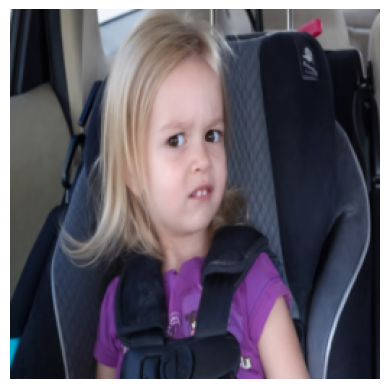

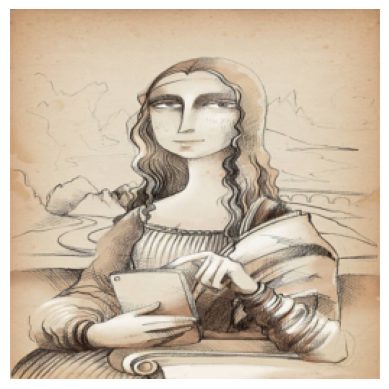

In [20]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),                  # resize shorter side to 512              # then random crop to 256x256
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
content = transform(Image.open(r'/kaggle/input/datasets/quphine/gatys-style-transfer/content.png').convert('RGB'))
style = transform(Image.open(r'/kaggle/input/datasets/quphine/gatys-style-transfer/style.jpg'))
plt_img(denormalize(content))
plt_img(denormalize(style))

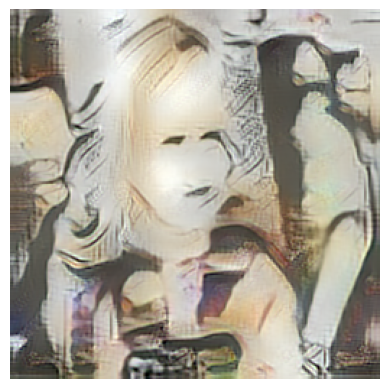

In [23]:
import torch
from collections import OrderedDict

# Initialize model
model = StyleTransferModel()
model.to(DEVICE)
model.eval()

# Load checkpoint safely
state_dict = torch.load(
    "/kaggle/input/models/quphine/adain-impl/pytorch/default/1/model.pth",
    map_location=DEVICE
)

# Strip 'module.' prefix if present
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")  # remove 'module.' if it exists
    new_state_dict[name] = v

# Load into model
model.load_state_dict(new_state_dict)

# Run inference
with torch.no_grad():
    gen = model(content.unsqueeze(0), style.unsqueeze(0))

# Visualize
plt_img(denormalize(gen[1].squeeze(0)))
